# Demand on Australia Day vs Temperature
- test plotting
- using demand substation and weather station data
- Jemena and Essedon airport (jemena distributes electricity to essedon)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

## Load demand data

In [3]:
demand_path = Path(
    "/home/565/pv3484/aus_substation_electricity/data/cleaned_data/VIC/Jemena_VIC/Jemena_VIC_2015_cleaned.csv"
)
demand = pd.read_csv(demand_path)

# Convert demand column to numeric RIGHT HERE
demand["ES"] = pd.to_numeric(demand["ES"], errors="coerce")

# Standardise timestamp
demand = demand.rename(columns={"StartDeliveryTime": "datetime"})
demand["datetime"] = pd.to_datetime(demand["datetime"])

## Load temp data

In [4]:
# Load temp data
temp_path = Path(
    "/home/565/pv3484/aus_substation_electricity/data/cleaned_data/VIC/cleaned_obs/086038_ESSENDON_AIRPORT_cleaned.parquet"
)
temp = pd.read_parquet(temp_path)
temp["datetime"] = pd.to_datetime(temp["datetime"])

# Convert BOTH columns to numeric BEFORE filtering/resampling
temp["air_temperature_in_degrees_celsius"] = pd.to_numeric(
    temp["air_temperature_in_degrees_celsius"], errors="coerce"
)

temp["average_wind_speed_in_last_5_minutes_in_km/h_where_observations_count_>=_2"] = pd.to_numeric(
    temp["average_wind_speed_in_last_5_minutes_in_km/h_where_observations_count_>=_2"],
    errors="coerce"
)

## Filter Aus Day

In [5]:
start = "2015-01-26 00:00"
end   = "2015-01-26 23:59"

demand_day = demand[(demand["datetime"] >= start) & (demand["datetime"] <= end)]
temp_day   = temp[(temp["datetime"] >= start) & (temp["datetime"] <= end)]

## Resample to hourly

In [6]:
demand_hourly = (
    demand_day
    .set_index("datetime")
    .resample("1h")
    .mean(numeric_only=True)
)

temp_hourly = (
    temp_day
    .set_index("datetime")
    .resample("1h")
    .mean(numeric_only=True)
)

## Plotting

In [7]:
# -- Dual Axis
fig, ax1 = plt.subplots(figsize=(12,6))

# Temperature (left axis)
ax1.plot(
    temp_hourly.index,
    temp_hourly["average_wind_speed_in_last_5_minutes_in_km/h_where_observations_count_>=_2"],
    color="blue",
    label="Wind Speed (°C)"
)
ax1.set_xlabel("Time of Day")
ax1.set_ylabel("Temperature (°C)", color="blue")
ax1.tick_params(axis="y", labelcolor="b")

# Demand (right axis)
ax2 = ax1.twinx()
ax2.plot(
    demand_hourly.index,
    demand_hourly["ES"],   # adjust if your demand column differs
    color="red",
    label="Electricity Demand"
)
ax2.set_ylabel("Electricity Demand", color="red")
ax2.tick_params(axis="y", labelcolor="red")


# -- X axis formatting
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

# -- Title + grid
plt.title("Essedon Australia Day 2015 — Temperature vs Electricity Demand (Hourly)")

plt.tight_layout()
plt.close()

In [ ]:
print(temp_hourly.columns)

# Demand on As Day vs Wind Speed

/jobfs/158931257.gadi-pbs/ipykernel_228376/919998974.py:49: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H")
/jobfs/158931257.gadi-pbs/ipykernel_228376/919998974.py:56: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H")


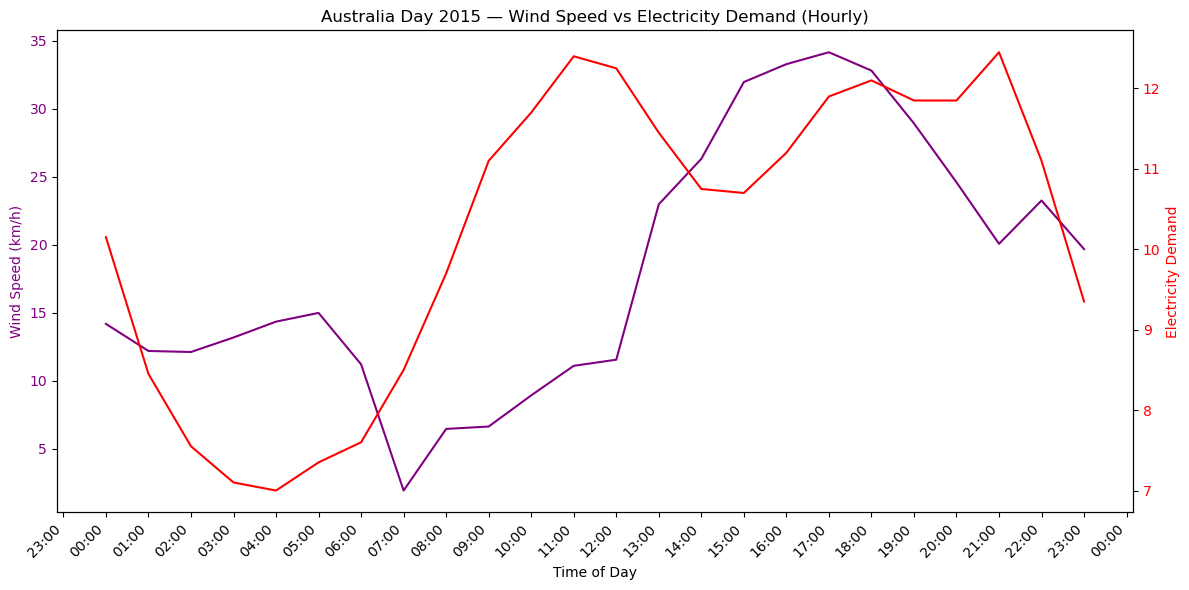

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# ---------------------------------------------------------
# Load demand data
# ---------------------------------------------------------
demand_path = Path(
    "/home/565/pv3484/aus_substation_electricity/data/cleaned_data/VIC/Jemena_VIC/Jemena_VIC_2015_cleaned.csv"
)
demand = pd.read_csv(demand_path)

# Convert demand column to numeric
demand["ES"] = pd.to_numeric(demand["ES"], errors="coerce")

# Standardise timestamp
demand = demand.rename(columns={"StartDeliveryTime": "datetime"})
demand["datetime"] = pd.to_datetime(demand["datetime"])

# ---------------------------------------------------------
# Load windspeed data
# ---------------------------------------------------------
temp_path = Path(
    "/home/565/pv3484/aus_substation_electricity/data/cleaned_data/VIC/cleaned_obs/086038_ESSENDON_AIRPORT_cleaned.parquet"
)
temp = pd.read_parquet(temp_path)
temp["datetime"] = pd.to_datetime(temp["datetime"])

# Convert windspeed column to numeric
winds_col = "average_wind_speed_in_last_5_minutes_in_km/h_where_observations_count_>=_2"
temp[winds_col] = pd.to_numeric(temp[winds_col], errors="coerce")

# ---------------------------------------------------------
# Filter to Australia Day 2015
# ---------------------------------------------------------
start = "2015-01-26 00:00"
end   = "2015-01-26 23:59"

demand_day = demand[(demand["datetime"] >= start) & (demand["datetime"] <= end)]
temp_day   = temp[(temp["datetime"] >= start) & (temp["datetime"] <= end)]

# ---------------------------------------------------------
# Resample both to hourly means
# ---------------------------------------------------------
demand_hourly = (
    demand_day
    .set_index("datetime")
    .resample("1H")
    .mean(numeric_only=True)
)

temp_hourly = (
    temp_day
    .set_index("datetime")
    .resample("1H")
    .mean(numeric_only=True)
)

# ---------------------------------------------------------
# Dual-axis plot
# ---------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(12,6))

# Windspeed (left axis)
ax1.plot(
    temp_hourly.index,
    temp_hourly[winds_col],
    color="purple",
    label="Wind Speed (km/h)"
)
ax1.set_xlabel("Time of Day")
ax1.set_ylabel("Wind Speed (km/h)", color="purple")
ax1.tick_params(axis="y", labelcolor="purple")

# Demand (right axis)
ax2 = ax1.twinx()
ax2.plot(
    demand_hourly.index,
    demand_hourly["ES"],
    color="red",
    label="Electricity Demand"
)
ax2.set_ylabel("Electricity Demand", color="red")
ax2.tick_params(axis="y", labelcolor="red")

# ---------------------------------------------------------
# X-axis formatting: hourly ticks + rotated labels
# ---------------------------------------------------------
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

# ---------------------------------------------------------
# Title + grid
# ---------------------------------------------------------
plt.title("Australia Day 2015 — Wind Speed vs Electricity Demand (Hourly)")

plt.tight_layout()
plt.show()

In [ ]:
print(temp_hourly.columns.tolist())